In [1]:
import sys
print(sys.executable)

/home/iskender/fixed-point-quantization-nn/.venv/bin/python


In [2]:
import numpy as np
import matplotlib.pyplot as plt

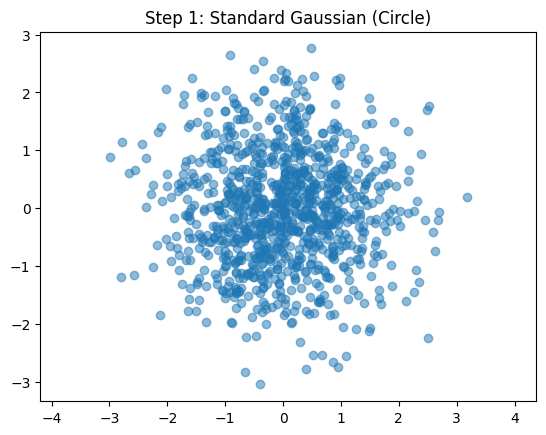

In [3]:
np.random.seed(0)

n = 1000

# Standard Gaussian (mean=0, identity covariance)
X = np.random.randn(n, 2)

plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.title("Step 1: Standard Gaussian (Circle)")
plt.axis('equal')
plt.show()

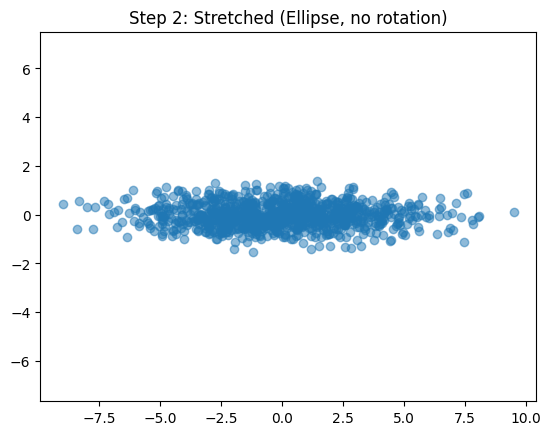

In [5]:
# Stretch factors (like eigenvalues)
stretch = np.array([[3, 0],
                    [0, 0.5]])

X_stretched = X @ stretch

plt.scatter(X_stretched[:, 0], X_stretched[:, 1], alpha=0.5)
plt.title("Step 2: Stretched (Ellipse, no rotation)")
plt.axis('equal')
plt.show()

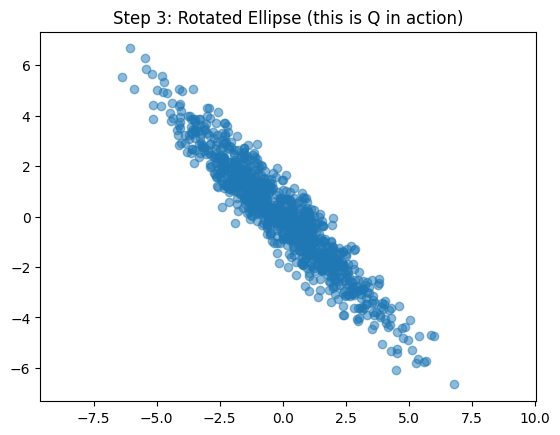

In [6]:
theta = np.pi / 4  # 45 degrees

Q = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

X_rotated = X_stretched @ Q

plt.scatter(X_rotated[:, 0], X_rotated[:, 1], alpha=0.5)
plt.title("Step 3: Rotated Ellipse (this is Q in action)")
plt.axis('equal')
plt.show()

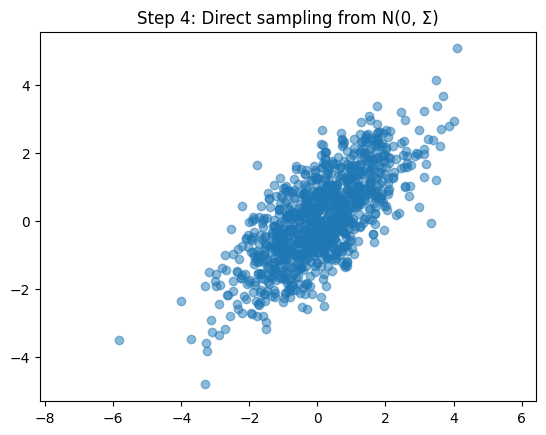

In [7]:
# Eigenvalues (stretching)
Lambda = np.diag([3, 0.5])

# Covariance matrix
Sigma = Q @ Lambda @ Q.T

# Sample directly
X_real = np.random.multivariate_normal(
    mean=[0, 0],
    cov=Sigma,
    size=n
)

plt.scatter(X_real[:, 0], X_real[:, 1], alpha=0.5)
plt.title("Step 4: Direct sampling from N(0, Σ)")
plt.axis('equal')
plt.show()

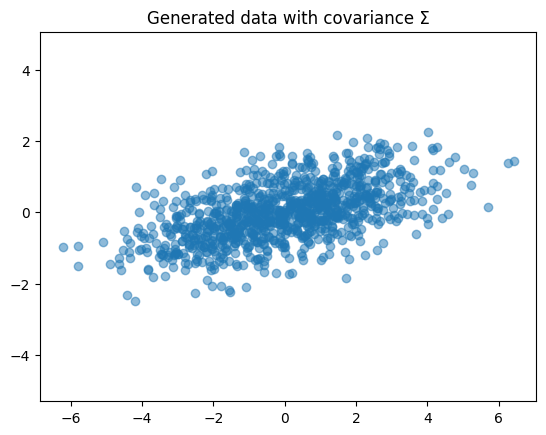

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
n = 1000

# Step 1: random noise
Z = np.random.randn(n, 2)

# Step 2: define covariance
Sigma = np.array([[3, 2],
                  [2, 2]])

# Step 3: Cholesky
L = np.linalg.cholesky(Sigma)

# Step 4: transform
X = Z @ L

plt.scatter(X[:,0], X[:,1], alpha=0.5)
plt.axis('equal')
plt.title("Generated data with covariance Σ")
plt.show()